In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("cleaned_data.csv")
df

,crop_name,soil_type,soil_moisture_level,temperature,humidity,rainfall,region_name,season,crop_age_in_days,predicted_disease_name
0,sugarcane,redsoil,46.0,27.0,86.0,1162.0,srikakulam,kharif,364.0,redrot
1,sugarcane,redsoil,43.0,29.0,76.0,1162.0,srikakulam,kharif,89.0,smut
2,sugarcane,redsoil,56.0,26.0,81.0,1162.0,srikakulam,kharif,14.0,settrot
3,sugarcane,redsoil,49.0,31.0,71.0,1162.0,srikakulam,kharif,179.0,wilt
4,sugarcane,redsoil,51.0,28.0,89.0,1162.0,srikakulam,kharif,149.0,rust
...,...,...,...,...,...,...,...,...,...,...
4411,brinjal,loamy,45.0,27.0,75.0,100.0,guntur,rabi,130.0,leafspot
4412,brinjal,loamy,45.0,27.0,75.0,100.0,guntur,rabi,130.0,collarrot
4413,turmeric,sandyloam,55.0,28.0,80.0,120.0,guntur,kharif,220.0,rhizomerot
4414,turmeric,sandyloam,55.0,28.0,80.0,120.0,guntur,kharif,220.0,leafspot


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.shape

(4416, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4416 entries, 0 to 4415
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   crop_name               4416 non-null   object 
 1   soil_type               4416 non-null   object 
 2   soil_moisture_level     4416 non-null   float64
 3   temperature             4416 non-null   float64
 4   humidity                4416 non-null   float64
 5   rainfall                4416 non-null   float64
 6   region_name             4416 non-null   object 
 7   season                  4416 non-null   object 
 8   crop_age_in_days        4416 non-null   float64
 9   predicted_disease_name  4416 non-null   object 
dtypes: float64(5), object(5)
memory usage: 345.1+ KB


In [5]:
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df

,crop_name,soil_type,soil_moisture_level,temperature,humidity,rainfall,region_name,season,crop_age_in_days,predicted_disease_name
0,62,44,46.0,27.0,86.0,1162.0,10,1,364.0,128
1,62,44,43.0,29.0,76.0,1162.0,10,1,89.0,155
2,62,44,56.0,26.0,81.0,1162.0,10,1,14.0,149
3,62,44,49.0,31.0,71.0,1162.0,10,1,179.0,198
4,62,44,51.0,28.0,89.0,1162.0,10,1,149.0,145
...,...,...,...,...,...,...,...,...,...,...
4411,15,29,45.0,27.0,75.0,100.0,4,4,130.0,98
4412,15,29,45.0,27.0,75.0,100.0,4,4,130.0,40
4413,67,51,55.0,28.0,80.0,120.0,4,1,220.0,131
4414,67,51,55.0,28.0,80.0,120.0,4,1,220.0,98


In [6]:
df.describe()

,crop_name,soil_type,soil_moisture_level,temperature,humidity,rainfall,region_name,season,crop_age_in_days,predicted_disease_name
count,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000
mean,41.235734,32.949728,54.411458,28.976449,75.213768,475.281250,8.027174,2.295516,77.065444,92.648777
std,17.953265,16.795289,13.826144,2.412573,8.905242,347.861234,4.305353,1.504343,58.409997,60.141924
min,0.000000,0.000000,20.000000,21.000000,44.000000,18.000000,0.000000,0.000000,14.000000,0.000000
25%,25.750000,13.000000,43.000000,27.000000,69.000000,120.000000,4.000000,1.000000,45.000000,38.750000
50%,43.000000,42.000000,55.000000,29.000000,76.000000,400.000000,8.000000,1.000000,60.000000,93.000000
75%,58.000000,45.000000,65.000000,30.000000,82.000000,792.000000,11.000000,4.000000,85.000000,145.000000
max,67.000000,57.000000,92.000000,38.000000,94.000000,1204.000000,15.000000,6.000000,365.000000,204.000000


In [7]:
df.isnull().sum()

crop_name                 0
soil_type                 0
soil_moisture_level       0
temperature               0
humidity                  0
rainfall                  0
region_name               0
season                    0
crop_age_in_days          0
predicted_disease_name    0
dtype: int64

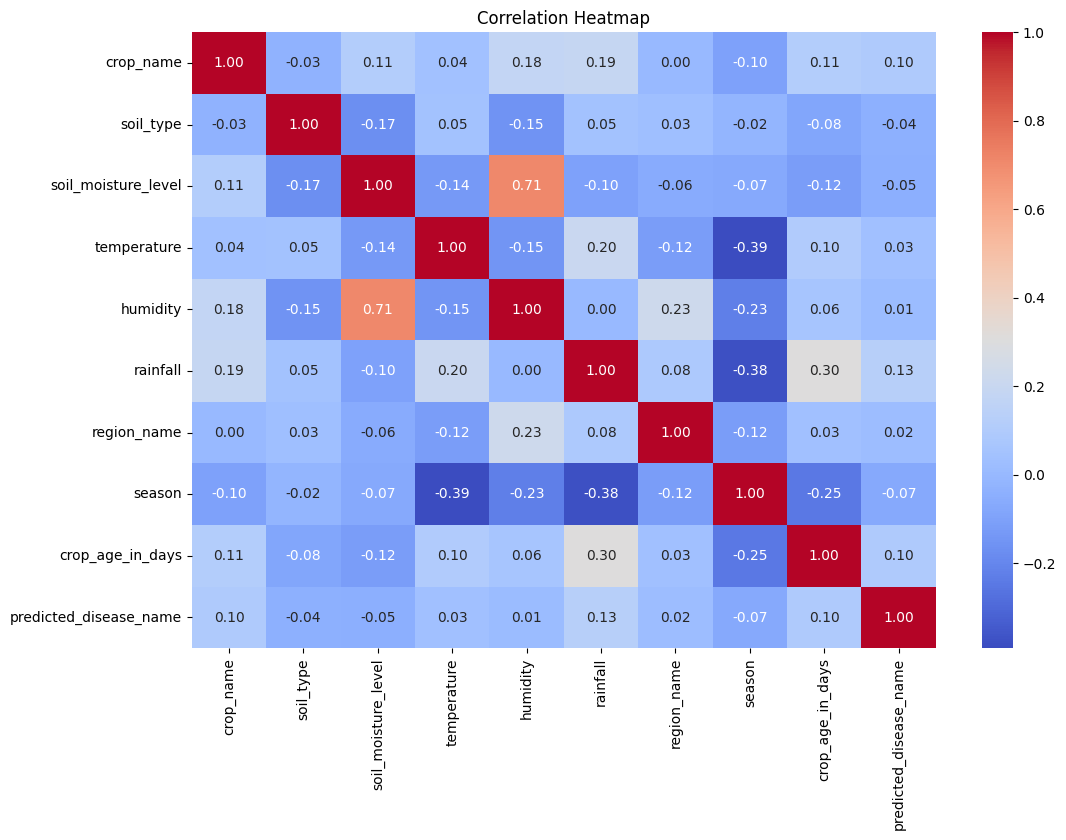

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

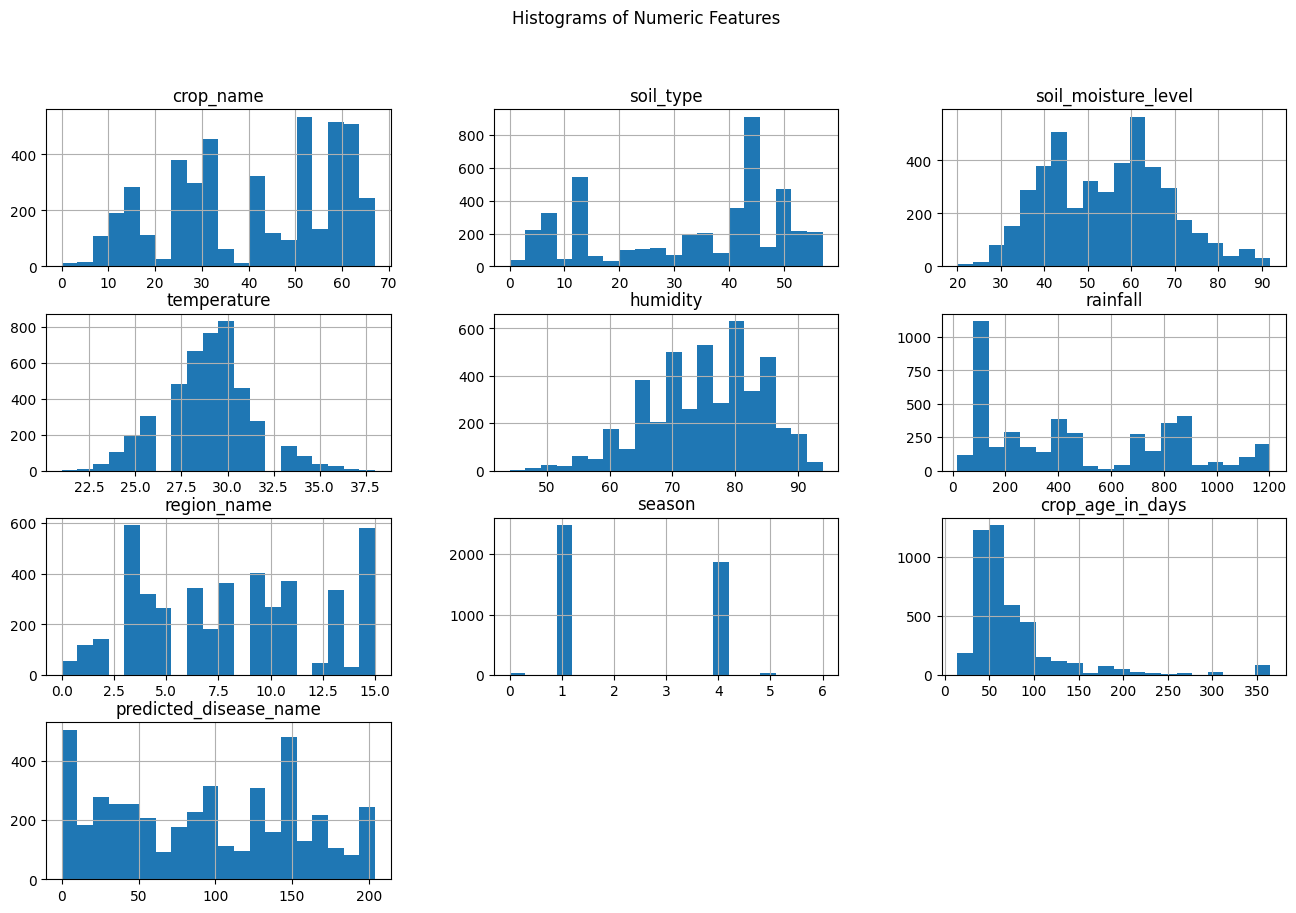

In [9]:
df.select_dtypes(include=np.number).hist(bins=20, figsize=(16, 10))
plt.suptitle("Histograms of Numeric Features")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [11]:
X = df.drop('predicted_disease_name', axis=1)
y = df['predicted_disease_name']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
y_pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.7975113122171946


In [13]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,max_depth=20,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8755656108597285


In [14]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Best Parameters:", grid_search.best_params_)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy Score: 0.8857466063348416


In [15]:
model=RandomForestClassifier(n_estimators=300,max_depth=None,min_samples_split=2,bootstrap=False,random_state=42)

In [16]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8857466063348416


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklea

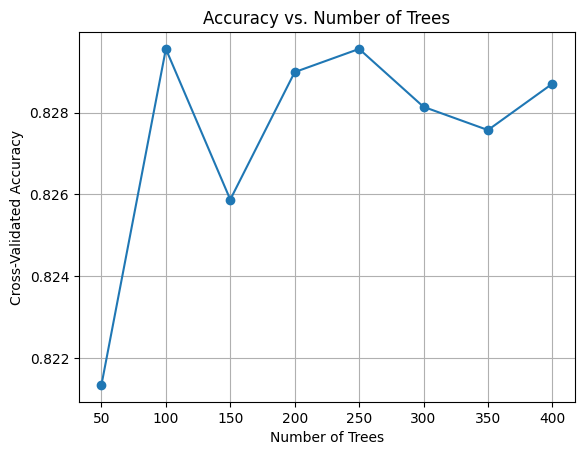

In [17]:
from sklearn.model_selection import cross_val_score
model = RandomForestClassifier(n_estimators=100, random_state=42)
train_scores = []
tree_counts = [50, 100, 150,200,250,300,350,400,]
for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    train_scores.append(scores.mean())
plt.plot(tree_counts, train_scores, marker='o')
plt.title("Accuracy vs. Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, bootstrap=False, max_depth=None, min_samples_split=2, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [20]:
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

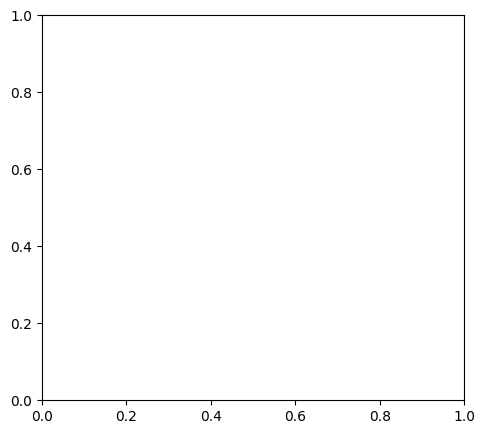

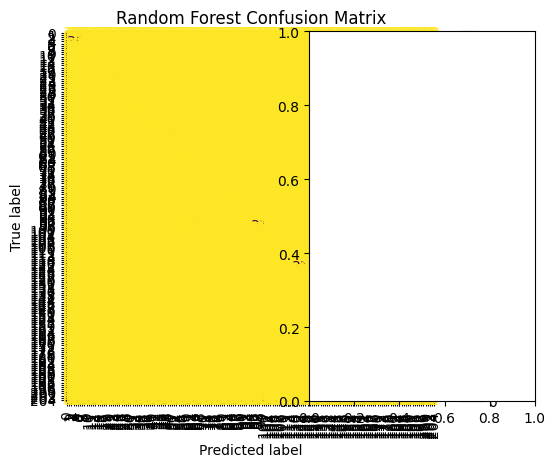

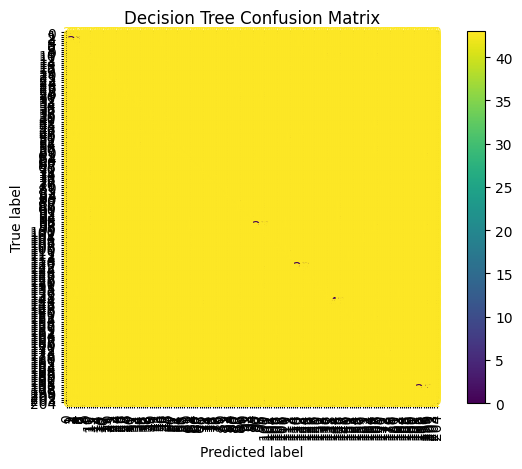

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, xticks_rotation='vertical')
plt.title("Random Forest Confusion Matrix")

plt.subplot(1, 2, 2)
ConfusionMatrixDisplay.from_predictions(y_test, dt_pred, xticks_rotation='vertical')
plt.title("Decision Tree Confusion Matrix")

plt.tight_layout()
plt.show()

In [22]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return [name, acc, pre, rec, f1]
results = []
results.append(evaluate_model("Random Forest", y_test, rf_pred))
results.append(evaluate_model("Decision Tree", y_test, dt_pred))
comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print(comparison_df)

           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.885747   0.892620  0.885747  0.881587
1  Decision Tree  0.797511   0.813262  0.797511  0.795239
